# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [1]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax   = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [ ]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard   = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [6]:
# Estadísticas originales
print("Estadísticas del dataset original:")
print(data.describe().round(4))

# Estadísticas con MinMaxScaler
print("\nEstadísticas después de MinMaxScaler:")
print(data_minmax.describe().round(4))

Estadísticas del dataset original:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count           150.0000          150.0000           150.0000   
mean              5.8433            3.0573             3.7580   
std               0.8281            0.4359             1.7653   
min               4.3000            2.0000             1.0000   
25%               5.1000            2.8000             1.6000   
50%               5.8000            3.0000             4.3500   
75%               6.4000            3.3000             5.1000   
max               7.9000            4.4000             6.9000   

       petal width (cm)  
count          150.0000  
mean             1.1993  
std              0.7622  
min              0.1000  
25%              0.3000  
50%              1.3000  
75%              1.8000  
max              2.5000  

Estadísticas después de MinMaxScaler:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count           150.0000          150.000

Al analizar las estadísticas, identifico las siguientes diferencias clave:

1. Al usar **MinMaxScaler**, todas las variables quedan transformadas al rango **[0, 1]**, donde el mínimo es 0.0 y el máximo es 1.0.
2. La media y desviación estándar cambian proporcionalmente, pero las **relaciones relativas** entre los datos se mantienen intactas.
3. La forma de la distribución original se preserva, ya que se trata de una **reescalación lineal** que no altera la estructura de los datos.

### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

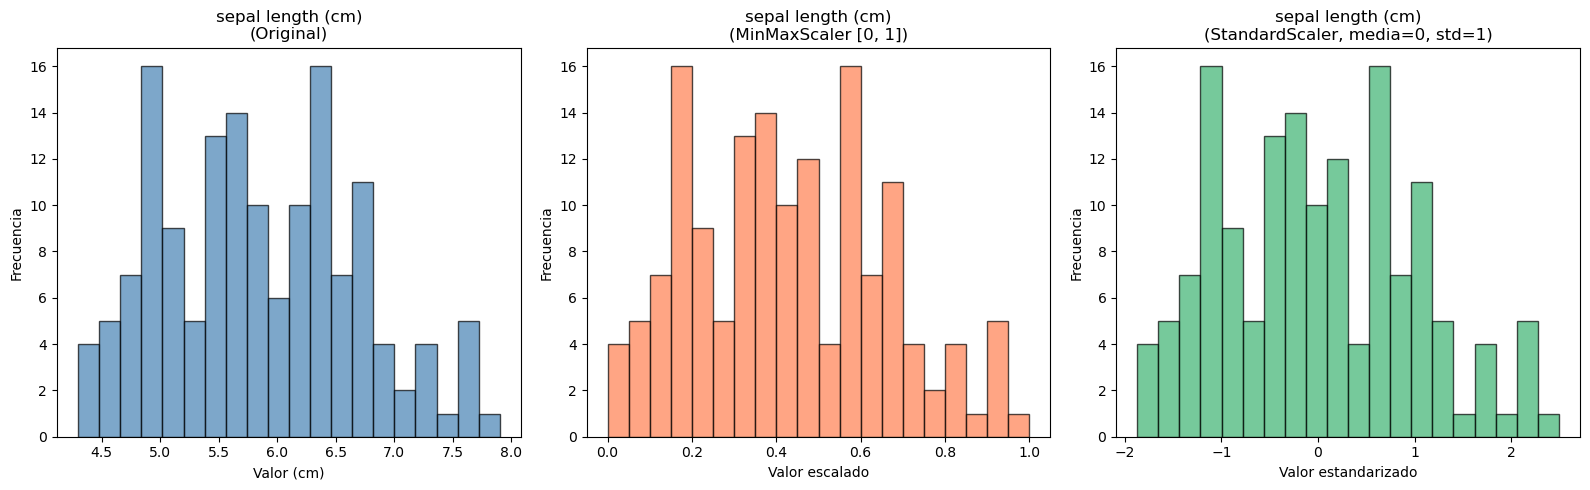

In [ ]:
# Distribución de 'sepal length (cm)' bajo los 3 escenarios
columna_analisis = 'sepal length (cm)'
figura, ejes     = plt.subplots(1, 3, figsize = (16, 5))

ejes[0].hist(
             data[columna_analisis],
             bins      = 20,
             color     = 'steelblue',
             edgecolor = 'black',
             alpha     = 0.7
            )
ejes[0].set_title(f'{columna_analisis}\n(Original)')
ejes[0].set_xlabel('Valor (cm)')
ejes[0].set_ylabel('Frecuencia')

ejes[1].hist(
             data_minmax[columna_analisis],
             bins      = 20,
             color     = 'coral',
             edgecolor = 'black',
             alpha     = 0.7
            )
ejes[1].set_title(f'{columna_analisis}\n(MinMaxScaler [0, 1])')
ejes[1].set_xlabel('Valor escalado')
ejes[1].set_ylabel('Frecuencia')

ejes[2].hist(
             data_standard[columna_analisis],
             bins      = 20,
             color     = 'mediumseagreen',
             edgecolor = 'black',
             alpha     = 0.7
            )
ejes[2].set_title(f'{columna_analisis}\n(StandardScaler, media=0, std=1)')
ejes[2].set_xlabel('Valor estandarizado')
ejes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Noto que la **forma de la distribución se mantiene idéntica** en los tres casos; lo que cambia es la escala del eje X. Al respecto, con MinMaxScaler los valores se comprimen al rango [0, 1], mientras que con StandardScaler se centran alrededor de 0 con valores negativos y positivos. Lo anterior confirma que ambas transformaciones son lineales y no distorsionan la distribución subyacente.

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

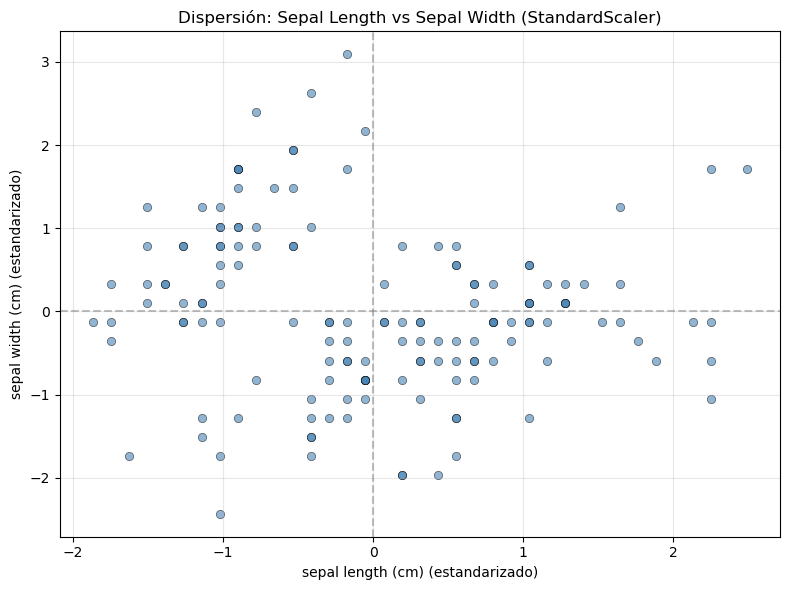

In [ ]:
# Gráfica de dispersión con StandardScaler
columna_x = 'sepal length (cm)'
columna_y = 'sepal width (cm)'

plt.figure(figsize = (8, 6))
plt.scatter(
            data_standard[columna_x],
            data_standard[columna_y],
            c          = 'steelblue',
            alpha      = 0.6,
            edgecolors = 'black',
            linewidth  = 0.5
           )
plt.xlabel(f'{columna_x} (estandarizado)')
plt.ylabel(f'{columna_y} (estandarizado)')
plt.title('Dispersión: Sepal Length vs Sepal Width (StandardScaler)')
plt.axhline(y = 0, color = 'gray', linestyle = '--', alpha = 0.5)
plt.axvline(x = 0, color = 'gray', linestyle = '--', alpha = 0.5)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

En la gráfica de dispersión observo que los datos estandarizados se distribuyen alrededor del origen (0, 0), lo que facilita interpretar qué observaciones se desvían de la media. Las líneas punteadas representan las medias de cada variable. Finalmente, detecto una **correlación negativa leve** entre ambas variables: a mayor longitud del sépalo, tiende a haber menor anchura.

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

In [ ]:
# Comparación de varianzas por variable
print("Comparación de varianzas por variable:")
print(f"\n{'Variable':<25} {'Original':<12} {'MinMax':<12} {'Standard':<12}")
print("-" * 61)

for columna in data.columns:
    varianza_original = data[columna].var()
    varianza_minmax   = data_minmax[columna].var()
    varianza_standard = data_standard[columna].var()
    print(f"{columna:<25} {varianza_original:<12.4f} {varianza_minmax:<12.4f} {varianza_standard:<12.4f}")

Comparación de varianzas por variable:

Variable                  Original     MinMax       Standard    
-------------------------------------------------------------
sepal length (cm)         0.6857       0.0529       1.0067      
sepal width (cm)          0.1900       0.0330       1.0067      
petal length (cm)         3.1163       0.0895       1.0067      
petal width (cm)          0.5810       0.1009       1.0067      


Considero que **StandardScaler es la técnica más adecuada** para el dataset Iris por las siguientes razones:

1. **Centra los datos** en media=0 y desviación estándar=1, lo cual es ideal para algoritmos que asumen distribución normal (SVM, regresión logística, redes neuronales).
2. El dataset Iris **no presenta outliers extremos**, por lo que StandardScaler funciona correctamente sin verse afectado por valores atípicos.
3. Si existieran outliers significativos, MinMaxScaler sería más sensible a ellos, ya que comprimiría la mayoría de los datos en un rango muy reducido al estar dominado por los valores extremos.